# 7.2. fMRI MVPA: Multi-Voxel Pattern Analysis

**Learning Objectives:**
- Understand the principles of **MVPA** (Multi-Voxel Pattern Analysis) for fMRI
- Learn how to build **voxel-wise feature matrices** from fMRI images
- Apply **scikit-learn** classifiers to decode experimental conditions from fMRI
- Implement **cross-validation** and evaluate decoding performance
- Run a **searchlight MVPA** analysis to localize informative brain regions
- Visualize and interpret **fMRI decoding maps**

**Key Concepts:**
- **MVPA / Decoding**: Predicting experimental conditions from spatial patterns of voxel activity
- **Searchlight**: Local decoding in small spheres that are moved throughout the brain
- **Masking**: Reducing fMRI data to voxels of interest (e.g., ventral temporal cortex)
- **Feature Matrix**: 2D array `(n_samples, n_features)` built from 4D fMRI data
- **Cross-Validation**: Estimating generalization performance while avoiding overfitting
- **Chance Level & Significance**: Interpreting decoding accuracy relative to chance


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from nilearn import datasets, image, plotting
from nilearn.input_data import NiftiMasker
from nilearn.decoding import SearchLight

from sklearn.model_selection import StratifiedKFold, cross_val_score, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')


/var/folders/4w/jb7nh9ns51vcx_1p3nn151800000gn/T/ipykernel_2155/3886051351.py:8: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiMasker


In [2]:
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 1. From Univariate fMRI to MVPA

Traditional fMRI analysis often asks:

> *"Which voxels are more active for condition A vs B?"*

This is usually answered with **univariate statistics** (e.g., GLM, voxel-wise t-tests).

In contrast, **MVPA / decoding** asks:

> *"Can we predict which condition the participant saw from the **pattern** of voxel activity?"*

Key differences:
- **Univariate**: Tests each voxel separately, ignoring correlations between voxels
- **Multivariate**: Uses patterns across many voxels simultaneously
- **MVPA** can be more sensitive to distributed representations (e.g., face vs house patterns)

In this tutorial we will:
- Use a classic **visual category** fMRI dataset
- Build a **feature matrix** from voxel data
- Train a **classifier** to decode stimulus category
- Run a **searchlight** analysis to find informative regions


## 2. Load Sample fMRI Data (Haxby Dataset)

We will use the **Haxby 2001** visual object recognition dataset, which is a standard benchmark for fMRI MVPA.

Participants viewed images from multiple categories (faces, houses, cats, etc.).
Here we will focus on decoding **faces vs houses**, a common example.


In [3]:
repo_root = Path("./").resolve().parents[1]
data_dir = repo_root / "datasets" / "fmri_mvpa_haxby"
data_dir.mkdir(parents=True, exist_ok=True)

# Fetch the Haxby dataset (single subject for this tutorial)
haxby_dataset = datasets.fetch_haxby(data_dir=str(data_dir))

print("Functional image file:", haxby_dataset.func[0])
print("Mask file (ventral temporal):", haxby_dataset.mask_vt[0])
print("Labels file:", haxby_dataset.session_target[0])


[fetch_haxby] Dataset found in /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_mvpa_haxby/haxby2001
Functional image file: /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_mvpa_haxby/haxby2001/subj2/bold.nii.gz
Mask file (ventral temporal): /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_mvpa_haxby/haxby2001/subj2/mask4_vt.nii.gz
Labels file: /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_mvpa_haxby/haxby2001/subj2/labels.txt


In [4]:
# Load behavioral labels (conditions over time)
labels = pd.read_csv(haxby_dataset.session_target[0], sep=" ")
conditions = labels["labels"].values

unique, counts = np.unique(conditions, return_counts=True)
print("Conditions and counts:")
for u, c in zip(unique, counts):
    print(f"  {u:10s}: {c}")

# Focus on a binary problem: faces vs houses
mask_faces_houses = np.isin(conditions, ["face", "house"])
conditions_binary = conditions[mask_faces_houses]

print("\nBinary decoding problem (faces vs houses):")
unique_b, counts_b = np.unique(conditions_binary, return_counts=True)
for u, c in zip(unique_b, counts_b):
    print(f"  {u:5s}: {c}")


Conditions and counts:
  bottle    : 108
  cat       : 108
  chair     : 108
  face      : 108
  house     : 108
  rest      : 588
  scissors  : 108
  scrambledpix: 108
  shoe      : 108

Binary decoding problem (faces vs houses):
  face : 108
  house: 108


## 3. Build a Voxel-wise Feature Matrix (Ventral Temporal Mask)

The Haxby dataset provides a **ventral temporal (VT) mask**, focusing analysis on
visual object-selective cortex.

We will:
1. Load the 4D fMRI image
2. Apply the VT mask using a `NiftiMasker`
3. Restrict to face/house time points
4. Build a feature matrix `X` and label vector `y`


In [5]:
# Load the functional image and VT mask
fmri_img = image.load_img(haxby_dataset.func[0])
vt_mask_img = image.load_img(haxby_dataset.mask_vt[0])

print("fMRI image shape:", fmri_img.shape)
print("VT mask shape:", vt_mask_img.shape)

# Set up a masker to extract voxel time series within the VT mask
masker = NiftiMasker(mask_img=vt_mask_img, standardize=True, detrend=True)
fmri_vt = masker.fit_transform(fmri_img)  # shape: (n_timepoints, n_voxels)

print("Masked fMRI data shape:", fmri_vt.shape)

# Restrict to face vs house time points
X = fmri_vt[mask_faces_houses]
y = (conditions_binary == "face").astype(int)  # 1=face, 0=house

print("\nFeature matrix X shape:", X.shape)
print("Labels y shape:", y.shape)
print(f"Faces (1):  {np.sum(y == 1)}")
print(f"Houses (0): {np.sum(y == 0)}")


fMRI image shape: (40, 64, 64, 1452)
VT mask shape: (40, 64, 64)
Masked fMRI data shape: (1452, 464)

Feature matrix X shape: (216, 464)
Labels y shape: (216,)
Faces (1):  108
Houses (0): 108


## 4. ROI-based Decoding with a Linear SVM

We now perform standard ROI-based decoding:
- Each **sample** = one fMRI volume at a time point
- Each **feature** = one voxel in ventral temporal cortex
- **Classifier**: Linear SVM with standardization
- **Cross-validation**: Stratified K-fold (e.g., 5-fold)


In [6]:
# chunks/run IDs from the labels file
groups = labels["chunks"].values[mask_faces_houses]

clf = make_pipeline(
    StandardScaler(with_mean=False),  # data already roughly standardized by masker
    SVC(kernel="linear", C=1.0)
)

logo = LeaveOneGroupOut()
scores = cross_val_score(clf, X, y, cv=logo.split(X, y, groups=groups))

print("Cross-validated accuracy (ROI-based, VT mask):")
for i, s in enumerate(scores, 1):
    print(f"  Fold {i}: {s:.3f}")
print(f"\nMean accuracy: {scores.mean():.3f} ± {scores.std():.3f}")


Cross-validated accuracy (ROI-based, VT mask):
  Fold 1: 1.000
  Fold 2: 1.000
  Fold 3: 1.000
  Fold 4: 1.000
  Fold 5: 1.000
  Fold 6: 1.000
  Fold 7: 1.000
  Fold 8: 1.000
  Fold 9: 1.000
  Fold 10: 1.000
  Fold 11: 1.000
  Fold 12: 1.000

Mean accuracy: 1.000 ± 0.000


Training-set accuracy (for illustration): 1.000


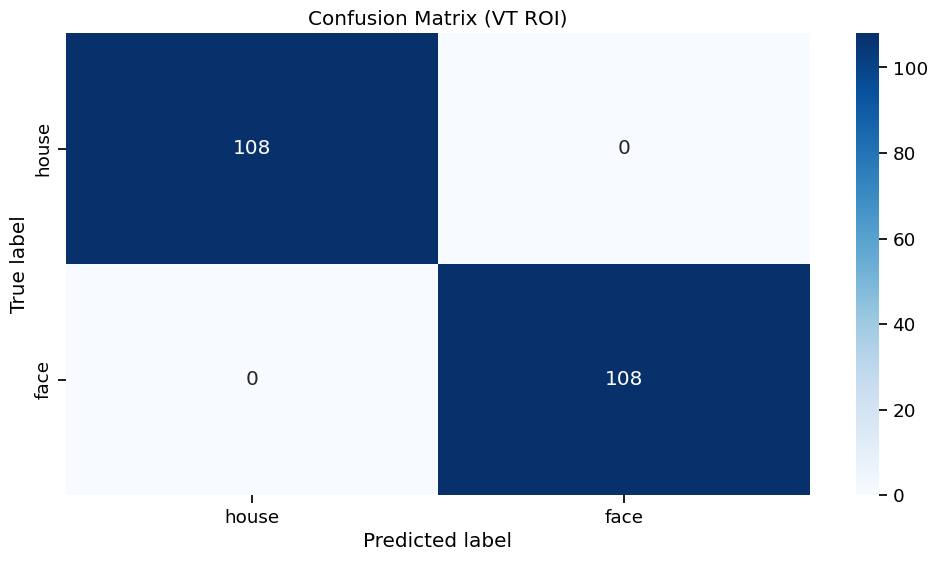


Classification report:
              precision    recall  f1-score   support

       house       1.00      1.00      1.00       108
        face       1.00      1.00      1.00       108

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216



In [7]:
# Fit on all data to inspect confusion matrix
clf.fit(X, y)
y_pred = clf.predict(X)

acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print(f"Training-set accuracy (for illustration): {acc:.3f}")

fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["house", "face"], yticklabels=["house", "face"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (VT ROI)")
plt.show()

print("\nClassification report:")
print(classification_report(y, y_pred, target_names=["house", "face"]))

## 5. Searchlight MVPA: Where Is Information Localized?

ROI-based decoding tells us **whether** information is present in ventral temporal cortex,
but not **where** within the brain it is localized.

A **searchlight** analysis performs decoding in a small spherical neighborhood around each voxel:
- Move a sphere voxel-by-voxel through the brain mask
- At each location, extract voxel values within the sphere, build a local feature matrix
- Train and evaluate a classifier (e.g., with cross-validation)
- Store the **local accuracy** at the center voxel

The result is an **accuracy map** that highlights regions carrying information about the categories.


In [8]:
from nilearn.image import index_img

# NOTE: Searchlight can be computationally expensive.
# To keep runtime reasonable in this tutorial, we:
# - Use only the ventral temporal mask
# - Use a modest radius

searchlight_radius = 5.6  # in mm (typical value in literature)

# Subset the 4D image to only the face/house volumes so it matches `y`.
fmri_img_sl = index_img(fmri_img, np.where(mask_faces_houses)[0])
y_sl = y  # length 216, matching the number of selected volumes

svc = SVC(kernel="linear", C=1.0)
cv_sl = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

searchlight = SearchLight(
    mask_img=vt_mask_img,
    process_mask_img=vt_mask_img,
    radius=searchlight_radius,
    estimator=svc,
    cv=cv_sl,
    n_jobs=1,
    verbose=1
)

print("Running searchlight MVPA (this may take a few minutes)...")
searchlight.fit(fmri_img_sl, y_sl)

searchlight_scores = searchlight.scores_  # 3D volume of accuracy values in mask space
print("Searchlight finished.")


Running searchlight MVPA (this may take a few minutes)...
[SearchLight.fit] Job #1, processed 0/464 steps (0.00%, 424.0 seconds remaining)
[SearchLight.fit] Job #1, processed 10/464 steps (2.16%, 35.5 seconds remaining)
[SearchLight.fit] Job #1, processed 20/464 steps (4.31%, 55.6 seconds remaining)
[SearchLight.fit] Job #1, processed 30/464 steps (6.47%, 53.4 seconds remaining)
[SearchLight.fit] Job #1, processed 40/464 steps (8.62%, 52.1 seconds remaining)
[SearchLight.fit] Job #1, processed 50/464 steps (10.78%, 50.5 seconds remaining)
[SearchLight.fit] Job #1, processed 60/464 steps (12.93%, 55.2 seconds remaining)
[SearchLight.fit] Job #1, processed 70/464 steps (15.09%, 50.7 seconds remaining)
[SearchLight.fit] Job #1, processed 80/464 steps (17.24%, 51.4 seconds remaining)
[SearchLight.fit] Job #1, processed 90/464 steps (19.40%, 54.9 seconds remaining)
[SearchLight.fit] Job #1, processed 100/464 steps (21.55%, 54.7 seconds remaining)
[SearchLight.fit] Job #1, processed 110/464 

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.8min finished


Mean searchlight accuracy (within VT mask): 0.684


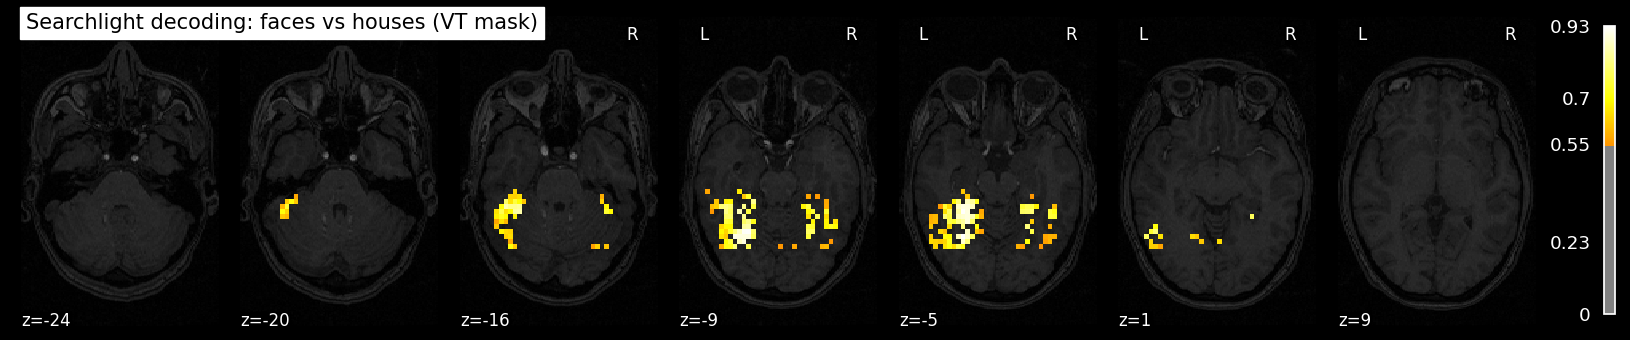

In [9]:
# Turn the searchlight scores into a NIfTI image and visualize
searchlight_img = image.new_img_like(vt_mask_img, searchlight_scores)

mean_acc = np.nanmean(searchlight_scores[searchlight_scores > 0])
print(f"Mean searchlight accuracy (within VT mask): {mean_acc:.3f}")

display = plotting.plot_stat_map(
    searchlight_img,
    bg_img=haxby_dataset.anat[0],
    threshold=0.55,  # highlight regions above ~chance (0.5)
    display_mode="z",
    cut_coords=7,
    cmap="hot",
    title="Searchlight decoding: faces vs houses (VT mask)"
)
plt.show()


## 6. Interpreting MVPA Results

- **Above-chance accuracy** in VT cortex confirms that this region carries information
  about visual category (faces vs houses).
- The **searchlight map** localizes where decoding is strongest, often in classic
  object-selective regions.
- Always interpret decoding results with care:
  - Chance level and confidence intervals matter
  - Spatial smoothing, mask choice, and preprocessing all influence results
  - MVPA detects *information*, not necessarily *activation increases*.
